# Joint Diffusion training

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)

In [1]:
import os
import sys
from pathlib import Path
import time
import json
#import diffusers
sys.path.append(os.path.abspath("diffusionsim"))
import diffusionsim.training_utils as tru
import torch
import torch.nn as nn
from dataclasses import dataclass, asdict, field
from diffusionsim.trainers import *
import pprint

In [2]:
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Define Configs

In [3]:
from pprint import pprint
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True

In [12]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.20, 0.15]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.0, 0.0, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [0.0, 10.0, 0.0, 10.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.loss_schedule = {'mse': 0, 'distribution': 5, 'diffusion': 5}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)




In [5]:
def setup_diffusion_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "xbatch"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [1.0]
    tconfigs, mconfigs = [], []

    learning_rates = [5e-5, 5e-5, 5e-5, 5e-5]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.lr_scheduler = None
        tconfig.lr_warmup_steps = 500
        tconfig.max_T_sample = 51
        tconfig.clip_gradients = True

        unet = tru.UNetParams()
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels
        unet.layers_per_block = 1
        unet.norm_num_groups = 2

        scheduler = tru.SchedulerParams()
        scheduler.beta_schedule = "linear"
        scheduler.clip_sample = False
        scheduler.clip_sample_range = 4.0
        scheduler.beta_end = 0.02

        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        mconfig.model_type = 'ddom_diffusion'
        mconfig.data_vars = data_vars

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)



### Playground for testing scripts

In [6]:
from sklearn.mixture import GaussianMixture
from matplotlib import pyplot as plt
import scipy.stats as stats
import numpy as np

#### Diff training

In [6]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "trial1"

num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [4]:
tconfigs, mconfigs, dconfig = setup_run(num_models, exp_id, run_id,
              data_vars='v1', batch_size=128)

dconfig.train_test_split = [0.001]

In [5]:
trainer = DiffusionTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [7]:
trainer.train(num_epochs=1)

Getting ready to train 3 model(s) for 1 epochs
Training for 1 epochs


{"event": "epoch start", "time": 1743658643.1590219, "pid": 1742437, "epoch": 0}
{"event": "batch-0 start", "time": 1743658645.2592452, "pid": 1742437, "batch": 0}
{"event": "run-batch start", "time": 1743658645.259493, "pid": 1742437}
{"event": "run-batch end", "time": 1743658713.6404977, "pid": 1742437, "duration": 68.38098978996277, "trial_1a": 1.1157360076904297, "trial_1b": 1.1225813627243042, "trial_1c": 1.1136373281478882}
{"event": "batch-0 end", "time": 1743658713.6414442, "pid": 1742437, "batch": 0, "duration": 68.38219618797302}


Currently at epoch 0, step 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1a-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1b-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1c-ckpt.pt
Finished training 3 model(s) for 1 epochs.


{"event": "epoch end", "time": 1743658714.4111528, "pid": 1742437, "epoch": 0, "duration": 71.252121925354, "epoch_loss": {"trial_1a": [1.1157360076904297], "trial_1b": [1.1225813627243042], "trial_1c": [1.1136373281478882]}}


In [18]:
print(trainer.dataloaders['train'].dataset.data.sizes)
trainer.dataloaders['train'].dataset.bgen._batch_selectors.selectors


Frozen({'time': 210, 'lev': 60, 'ncol': 384})


{0: [{'time': slice(0, 128, None),
   'lev': slice(0, 60, None),
   'ncol': slice(0, 384, None)}]}

In [5]:
dataloaders, indices = tru.load_dataloaders(dconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [6]:
dataloader_dict = dict(train=dataloaders[0])
loss_fn = torch.nn.MSELoss()

In [6]:
#mconfig.unet.block_out_channels = (128, 256, 512) #if dconfig.data_vars == "v1" else (256, 512, 1024)
#model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, exp_id, exp_dir)

In [54]:
bind = ds.bgen._batch_selectors.selectors
bind[5]

[{'time': slice(2560, 3072, None),
  'lev': slice(0, 60, None),
  'ncol': slice(0, 384, None)}]

#### Train Clim

In [8]:
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "testing_just_mse"

In [5]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTesting"
run_id = "test_trial0"
num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [9]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)

In [13]:
#dconfig.train_test_split = [0.001, 0.001]

pprint(dconfig)
dconfig.train_test_split = [0.001, 0.001]
dconfig.shuffle_indices = False

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.001, 0.001],
           dataloader_params=DataLoaderParams(batch_size=24576,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=False),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [225]:
trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)
self = trainer
trainer.current_epoch = 7
trainer.log = True
trainer.distloss_var_counts = {}
trainer.gradients = {}

In [152]:
len(trainer.dataloaders['train']), #trainer.indices[0]


(3,)

In [171]:
trainer.current_epoch = 7
trainer._return_loss_weights(tconfigs[3])

{'mse': 1.0, 'distribution': 0.01, 'diffusion': 10.0}

#### Sanity Checking run_batch

In [223]:
import copy

def params_of(model):
    return [p.detach().clone() for p in model.parameters()][-2]

In [224]:
og_models = [copy.deepcopy(trainer.models[run_id]) for run_id in trainer.run_ids]

In [226]:
import copy

for key in trainer.models:
    model = copy.deepcopy(og_models[0])
    tconfig = trainer.training_configs[key]
    trainer.models[key] = model
    print(params_of(trainer.models[key])[:2, :2], "\n")
    self.optimizers[key] = tru.create_optimizer(model, tconfig)


tensor([[ 0.0116,  0.0311],
        [ 0.0038, -0.0500]]) 

tensor([[ 0.0116,  0.0311],
        [ 0.0038, -0.0500]]) 

tensor([[ 0.0116,  0.0311],
        [ 0.0038, -0.0500]]) 

tensor([[ 0.0116,  0.0311],
        [ 0.0038, -0.0500]]) 



In [227]:
x, y = next(iter(trainer.dataloaders['train']))

{"event": "get-item start", "time": 1751548843.816021, "pid": 3865942, "batch_idx": 0}


{"event": "get-item end", "time": 1751548845.2488296, "pid": 3865942, "batch_idx": 0, "duration": 1.432807207107544}


In [232]:

def _run_batch(self, x, y, phase, step):
    self.gradients = {}
    if(self.log):
        t0 = tru.log_event("run-batch start", step=step)
    batch_losses = {}
    params = []
    after_params = []
    for run_id in self.run_ids:
        batch_losses[run_id] = {}
        model, optimizer, tconfig = self.models[run_id], self.optimizers[run_id], self.training_configs[run_id]
        lws = self._return_loss_weights(tconfig)
        y_hat = model(x)
        mse_loss = self.loss_fn(y_hat, y)
        if(phase == 'train' and self._gradients_ops(run_id, "mse", mse_loss, step)):
            self.nan_incidents[run_id][-1]['inputs'] = (x, y)
        total_loss = lws['mse'] * mse_loss
        batch_losses[run_id]['mse'] = mse_loss.item()
        if('distribution' in self.tracked_losses):
            dist_loss, VAR_IND = self.distribution_loss(y_hat, y, tconfig, step)
            if(phase == 'train' and self._gradients_ops(run_id, "distribution", dist_loss, step)):
                self.nan_incidents[run_id][-1]['inputs'] = (x, y)
            self.distloss_var_counts.setdefault(run_id, defaultdict(int))[VAR_IND] += 1
            batch_losses[run_id]['distribution'] = dist_loss.item()
            batch_losses[run_id]['VAR_IND'] = VAR_IND
            if(lws['distribution'] > 0 and not torch.isnan(dist_loss)):
                total_loss += lws['distribution'] * dist_loss
            
        if('diffusion' in self.tracked_losses):
            diff_loss = self.diffusion_loss(y_hat, run_id)
            if(phase == 'train' and self._gradients_ops(run_id, "diffusion", diff_loss, step)):
                self.nan_incidents[run_id][-1]['inputs'] = (x, y)
            batch_losses[run_id]['diffusion'] = diff_loss.item()
            if(lws['diffusion'] > 0 and not torch.isnan(diff_loss)):  
                total_loss += lws['diffusion'] * diff_loss
        
        batch_losses[run_id]['total'] = total_loss.item()
        optimizer.zero_grad()
        print("\n\n", run_id, lws, total_loss)
        print(f"[{run_id}] total_loss.requires_grad = {total_loss.requires_grad}")
        print(f"[{run_id}] total_loss.grad_fn = {total_loss.grad_fn}")
        total_loss.backward(retain_graph=False)
        for name, p in model.named_parameters():
            print(f"[{run_id}] Param '{name}' grad: {'None' if p.grad is None else p.grad.norm().item()}")
        params.append(copy.deepcopy(params_of(model)))
        optimizer.step()
        after_params.append(copy.deepcopy(params_of(model)))
        if(self.lr_schedulers[run_id] is not None):
            self.lr_schedulers[run_id].step()
    losses = [batch_losses[run_id]['total'] for run_id in self.run_ids]
    if(self.log):
        tru.log_event("run-batch end", duration=time.time() - t0, loss=losses, step=step)
    return(batch_losses, params, after_params)


In [233]:
import torch

initial_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    initial_weights[key] = param.detach().clone()

batch_losses, params, after_params = _run_batch(trainer, x, y, phase='train', step=0)
new_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    new_weights[key] = param.detach().clone()
    print(f"{key} updated:", not torch.allclose(param, initial_weights[key]))

{"event": "run-batch start", "time": 1751549079.302436, "pid": 3865942, "step": 0}




 test_trial0a {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0} tensor(4.6359, grad_fn=<MulBackward0>)
[test_trial0a] total_loss.requires_grad = True
[test_trial0a] total_loss.grad_fn = <MulBackward0 object at 0x15542b87dde0>
[test_trial0a] Param '0.weight' grad: 0.2682901918888092
[test_trial0a] Param '0.bias' grad: 0.00936168059706688
[test_trial0a] Param '2.weight' grad: 0.4005536437034607
[test_trial0a] Param '2.bias' grad: 0.02108306996524334
[test_trial0a] Param '4.weight' grad: 0.4018572270870209
[test_trial0a] Param '4.bias' grad: 0.0557856559753418
[test_trial0a] Param '6.weight' grad: 0.4047260284423828
[test_trial0a] Param '6.bias' grad: 0.1205584779381752


 test_trial0b {'mse': 1.0, 'distribution': 0.0, 'diffusion': 10.0} tensor(4.6414, grad_fn=<AddBackward0>)
[test_trial0b] total_loss.requires_grad = True
[test_trial0b] total_loss.grad_fn = <AddBackward0 object at 0x15544b0b7ca0>
[test_trial0b] Param '0.weight' grad: 0.26853424310684204
[test_trial0b] Param '0.bias' g

{"event": "run-batch end", "time": 1751549094.8833666, "pid": 3865942, "duration": 15.580928325653076, "loss": [4.635891437530518, 4.641400337219238, 4.838864326477051, 4.850637912750244], "step": 0}


In [235]:
params[0] == after_params[0]

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

In [212]:
after_params[0]

Parameter containing:
tensor([[-0.0047, -0.0448, -0.0130,  ..., -0.0220,  0.0306,  0.0589],
        [ 0.0488, -0.0109,  0.0456,  ..., -0.0357, -0.0203, -0.0419],
        [-0.0320, -0.0429,  0.0164,  ...,  0.0287, -0.0417,  0.0537],
        ...,
        [-0.0166,  0.0358,  0.0408,  ..., -0.0107, -0.0453, -0.0205],
        [ 0.0595,  0.0007,  0.0016,  ..., -0.0062, -0.0186,  0.0194],
        [-0.0495, -0.0374,  0.0210,  ..., -0.0340,  0.0192, -0.0013]],
       requires_grad=True)

In [208]:
[id(trainer.optimizers[key]) for key in trainer.optimizers]

[23451253503136, 23451229812592, 23451254251040, 23451254247104]

In [199]:
params

[tensor([[-2.3745e-06, -1.7322e-05,  3.0623e-09,  ..., -5.1141e-05,
          -1.4645e-05, -4.9369e-05],
         [-1.6753e-06, -1.5339e-05,  8.0638e-10,  ..., -5.0422e-05,
          -1.3069e-05, -4.9150e-05],
         [-3.9235e-07, -1.4205e-05,  1.0547e-09,  ..., -3.3207e-05,
          -8.1474e-06, -4.1408e-05],
         ...,
         [ 7.9183e-07,  6.8799e-07, -1.4674e-08,  ..., -3.0205e-07,
          -5.7056e-06,  8.9869e-06],
         [ 1.0312e-06,  1.7430e-06, -6.9896e-09,  ...,  1.4938e-06,
          -4.0887e-06,  9.5696e-06],
         [ 7.0023e-07, -5.3371e-07, -4.7477e-09,  ..., -1.7283e-09,
          -3.4236e-06,  2.1317e-06]]),
 tensor([[-4.1707e-05, -3.0694e-04,  5.4656e-08,  ..., -8.9612e-04,
          -2.5809e-04, -8.7356e-04],
         [-2.7581e-05, -2.5180e-04,  1.1701e-08,  ..., -8.3284e-04,
          -2.1235e-04, -8.1041e-04],
         [-6.8439e-06, -2.4239e-04,  1.2780e-08,  ..., -5.6956e-04,
          -1.4094e-04, -7.0933e-04],
         ...,
         [ 1.4816e-05,  4

In [135]:
self = trainer
for run_id, grads in self.gradients.items():
    print(run_id, trainer.training_configs[run_id].loss_weights)
    for loss_type, gradloss in grads.items():
        print(loss_type, gradloss['2.weight'])``
    print()

test_trial0a {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
mse [(0.00011132767394883558, 0.0015931924572214484)]
distribution [(0.007619359530508518, 0.1007653996348381)]
diffusion [(0.007620595395565033, 0.10076785832643509)]

test_trial0b {'mse': 1.0, 'distribution': 0.0, 'diffusion': 10.0}
mse [(0.00023141878773458302, 0.002308514667674899)]
distribution [(0.03203132003545761, 0.444683700799942)]
diffusion [(0.0320325568318367, 0.4446859061717987)]

test_trial0c {'mse': 1.0, 'distribution': 0.01, 'diffusion': 0.0}
mse [(0.00022290182823780924, 0.002274084836244583)]
distribution [(0.003351801075041294, 0.3513255715370178)]
diffusion [(0.0033530325163155794, 0.35132598876953125)]

test_trial0d {'mse': 1.0, 'distribution': 0.01, 'diffusion': 10.0}
mse [(0.00011132767394883558, 0.0015931924572214484)]
distribution [(-0.00012356959632597864, 0.004842753522098064)]
diffusion [(1.245251269210712e-06, 7.70823589846259e-06)]



In [56]:
[trainer.training_configs[run_id].num_gaussians for run_id in trainer.run_ids]

[[3, 2, 3, 2], [3, 2, 3, 2], [3, 2, 3, 2], [3, 2, 3, 2]]

### testing training

In [30]:
trainer.bli = 1
trainer.train(1, log=True)

Getting ready to train 4 model(s) for 1 epochs
Saving configs to /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/trial2.json
Epoch 1/1
__________


{"event": "epoch-0 start", "time": 1748549804.799313, "pid": 973992}
{"event": "get-item start", "time": 1748549804.7999809, "pid": 973992, "batch_idx": 0}


Currently at epoch 0, step 0/3


{"event": "get-item end", "time": 1748549808.8293967, "pid": 973992, "batch_idx": 0, "duration": 4.029410123825073}
{"event": "run-batch start", "time": 1748549808.8428047, "pid": 973992, "step": 0}


log stepping at 0


{"event": "run-batch end", "time": 1748549811.3839962, "pid": 973992, "duration": 2.5411880016326904, "loss": [4.633231163024902, 5.381290912628174, 5.243656635284424, 6.908066272735596], "step": 0}
{"event": "get-item start", "time": 1748549811.3865929, "pid": 973992, "batch_idx": 2}
{"event": "get-item end", "time": 1748549815.2424629, "pid": 973992, "batch_idx": 2, "duration": 3.855865955352783}
{"event": "run-batch start", "time": 1748549815.2522297, "pid": 973992, "step": 1}


log stepping at 1


{"event": "run-batch end", "time": 1748549818.0895505, "pid": 973992, "duration": 2.8373167514801025, "loss": [4.590574264526367, 5.335712432861328, 5.836515426635742, 6.377585411071777], "step": 1}
{"event": "get-item start", "time": 1748549818.093885, "pid": 973992, "batch_idx": 1}
{"event": "get-item end", "time": 1748549821.7691803, "pid": 973992, "batch_idx": 1, "duration": 3.675291061401367}
{"event": "run-batch start", "time": 1748549821.7789483, "pid": 973992, "step": 2}


log stepping at 2



avg mse loss for epoch 0, run_id trial2a: 4.604272206624349
avg total loss for epoch 0, run_id trial2a: 4.604272206624349
new best! saving new checkpoint at epoch 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/checkpoints/best-trial2a-ckpt.pt
avg diffusion loss for epoch 0, run_id trial2a: 0.07061270127693813
avg distribution loss for epoch 0, run_id trial2a: 32.69928218052223
avg mse loss for epoch 0, run_id trial2b: 4.606588522593181
avg total loss for epoch 0, run_id trial2b: 5.349874496459961
new best! saving new checkpoint at epoch 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/checkpoints/best-trial2b-ckpt.pt
avg diffusion loss for epoch 0, run_id trial2b: 0.07432858645915985
avg distribution loss for epoch 0, run_id trial2b: 1.9653987288572292
avg mse loss for epoch 0, run_id trial2c: 4.620271682739258
avg total loss for epoch 0, run_id trial2c: 5.598298072814941
new best! saving new checkpoint at epoch 0
Model

{"event": "run-batch end", "time": 1748549824.4760468, "pid": 973992, "duration": 2.697093963623047, "loss": [4.589011192321777, 5.332620143890381, 5.714722156524658, 5.352270603179932], "step": 2}
{"event": "epoch-0 end", "time": 1748549824.4807637, "pid": 973992}


In [31]:
trainer.losses #incident  = trainer.nan_incidents['trial1b'][0]

{'trial2a': {'train': {'mse': [4.633231163024902,
    4.590574264526367,
    4.589011192321777],
   'total': [4.633231163024902, 4.590574264526367, 4.589011192321777],
   'diffusion': [0.07061993330717087, 0.0705714151263237, 0.0706467553973198],
   'distribution': [58.94259266535748,
    37.37349747533818,
    1.7817564008710352]}},
 'trial2b': {'train': {'mse': [4.635831356048584,
    4.5928192138671875,
    4.5911149978637695],
   'total': [5.381290912628174, 5.335712432861328, 5.332620143890381],
   'diffusion': [0.0745459496974945, 0.07428930699825287, 0.07415050268173218],
   'distribution': [2.531467244597772,
    1.5187162748012681,
    1.8460126671726471]}},
 'trial2c': {'train': {'mse': [4.641189098358154,
    4.606978893280029,
    4.61264705657959],
   'total': [5.243656635284424, 5.836515426635742, 5.714722156524658],
   'diffusion': [0.07177993655204773,
    0.07177162170410156,
    0.07180877774953842],
   'distribution': [60.24674519713407,
    122.95363672543111,
    1

In [22]:
print(incident.keys())
for name, p in incident['state_dict'].items():
    print(name, p.shape, torch.isnan(p).any())



dict_keys(['step', 'run_id', 'loss_type', 'msg', 'tensor_name', 'tensor_sample', 'state_dict'])
0.weight torch.Size([256, 124]) tensor(False)
0.bias torch.Size([256]) tensor(False)
2.weight torch.Size([256, 256]) tensor(False)
2.bias torch.Size([256]) tensor(False)
4.weight torch.Size([256, 256]) tensor(False)
4.bias torch.Size([256]) tensor(False)
6.weight torch.Size([128, 256]) tensor(False)
6.bias torch.Size([128]) tensor(False)


In [21]:
sample_model = tru.build_baseline_model(mconfigs[0]).to(device)
sample_model.eval()
sample_model.load_state_dict(incident['state_dict'])


<All keys matched successfully>

In [236]:
x, y = trainer.dataloaders['train'].dataset[335]

{"event": "get-item start", "time": 1748493236.7770863, "pid": 837663, "batch_idx": 335}
{"event": "get-item end", "time": 1748493248.063473, "pid": 837663, "batch_idx": 335, "duration": 11.286383152008057}


In [237]:
x, y = x.to(device), y.to(device)
y_hat = sample_model(x)
y_hat.shape, y.shape

(torch.Size([24576, 128]), torch.Size([24576, 128]))

In [239]:
trainer.distribution_loss(y_hat, y, tconfigs[0], 0)

(tensor(10.9021, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
 73)

In [93]:
a, b = None, None

In [247]:
step = 0
epsilon=1e-3
tconfig = tconfigs[0]
VAR_IND, num_gaussian = select_distloss_var(tconfig, step)
print(VAR_IND, num_gaussian)
assert isinstance(num_gaussian, int) and isinstance(VAR_IND, int), "num_gaussian and VAR_IND must be integers"
GMM = GaussianMixture(n_components=num_gaussian, reg_covar=epsilon)
GMM.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1, 1))
mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:]
pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:] 
var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:]
pi = torch.clamp(pi, min=epsilon)
var = torch.clamp(var, min=epsilon)

with torch.no_grad():
    h = 2 * torch.max(var).item()


bs, n_samples = tconfig.distloss_bs, tconfig.num_distloss_samples
batch_num = y_hat.shape[0] // bs
ix, jx = torch.randint(0, batch_num, (n_samples,)), torch.randint(0, batch_num, (n_samples,))
mask = ix == jx
while mask.any():
    ix[mask] = torch.randint(0, batch_num, (mask.sum(),))
    jx[mask] = torch.randint(0, batch_num, (mask.sum(),))
    mask = ix == jx
loss = 0
for i,j in zip(ix, jx):
    y1 = y_hat[i*bs : (i+1)*bs, VAR_IND]
    y2 = y_hat[j*bs : (j+1)*bs, VAR_IND]
    loss += u_q(y1, y2, mu, var, pi, h).mean()
    print(loss)
    if(loss.isnan().any()):
        break

60 2
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(31835.4251, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(64356.9469, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(96022.9895, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(128118.0478, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(161335.7233, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(195320.1538, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
tensor(False, device='cuda:0') tensor(False, device='cuda:0')
tensor(226631.7490, device='cu

In [227]:
def score_function(x, mu, var, pi, clamp_val=10, epsilon=1e-7):
    mahal = (x[:,None] - mu) ** 2 / (2 * var)
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - torch.clamp(mahal, max=clamp_val)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True)) + epsilon
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * torch.clamp((x[:,None] - mu) / var, max=clamp_val, min=-clamp_val)  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

def u_q(x_1, x_2, mu, var, pi, h):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    print(sq1.isnan().any(), sq2.isnan().any())

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    res = torch.outer(sq1, sq2)
    res += (sq1.reshape(-1,1) * diffs) / h**2
    res -= (sq2.reshape(1, -1) * diffs)/h**2
    res += (h**-2 - h**-4 * diffs ** 2)
    res = res * torch.exp(- (diffs ** 2) / (2 * h ** 2)) # kernel matrix
    return(res)

In [206]:
mu, pi, var

(tensor([[-1.1451, -1.1454]], device='cuda:0', dtype=torch.float64),
 tensor([[0.8392, 0.1608]], device='cuda:0', dtype=torch.float64),
 tensor([[0.0011, 0.0011]], device='cuda:0', dtype=torch.float64))

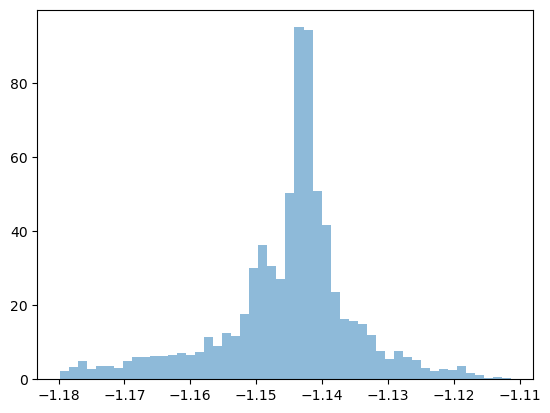

In [204]:
plt.hist(y[:, VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='Data')
plt.show()

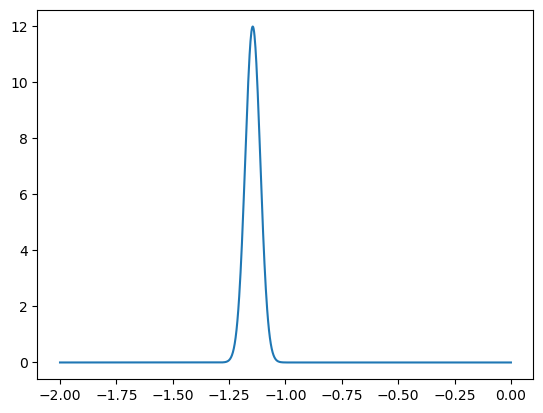

In [205]:
x = torch.linspace(-2, 0, 1000)
density, = eval_density(x, GMM)

plt.plot(x, density)

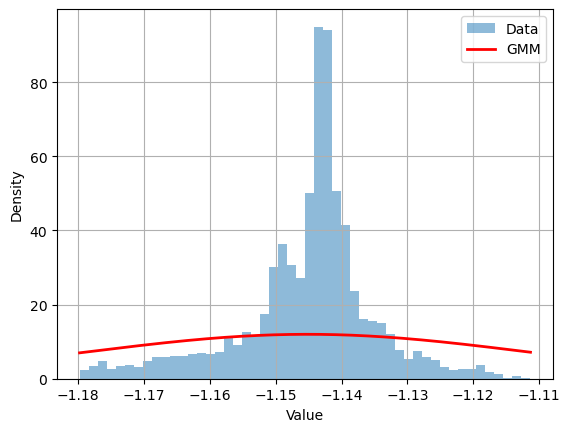

In [202]:
def eval_density(x, GMM=None, training=False, return_components=False):
    if(torch.is_tensor(x)):
        x = x.detach().cpu().reshape(-1, 1)
    elif(len(x.shape) == 1):
        x = x[:, None]
    if(GMM is None):
        GMM = GaussianMixture(n_components=2)
        GMM.fit(x)
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x,)

def plot_gmm_distribution(data, gmm, n_points=1000, components=False):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    # Create a range of x values to evaluate the GMM on
    x = torch.linspace(data.min(), data.max(), n_points)
    ret = eval_density(x, gmm, return_components=components)
    # Plot histogram of actual data
    plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
    # Plot GMM density
    plt.plot(x, ret[0], 'r-', lw=2, label='GMM')
    if(components):
        plt.plot(x, ret[1][:,0], 'b-', lw=2, label='Component 1')
        plt.plot(x, ret[1][:,1], 'g-', lw=2, label='Component 2')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    return(ret[0])

d = plot_gmm_distribution(y[:,VAR_IND].reshape(-1, 1), GMM)

In [135]:
GMM.means_, GMM.covariances_, GMM.weights_

(array([[-1.14240658],
        [-1.1636534 ]]),
 array([[[5.51086799e-05]],
 
        [[8.23181938e-05]]]),
 array([0.87004365, 0.12995635]))

In [16]:
trainer.losses

{'trial1a': {'train': {'mse': [4.659530162811279,
    4.641855239868164,
    4.6658172607421875],
   'total': [4.659530162811279, 4.641855239868164, 4.6658172607421875],
   'diffusion': [0.07212287187576294,
    0.07197009772062302,
    0.07212147861719131],
   'distribution': [1.6887024716882535,
    1.4819232760840662,
    11058.126625712297]},
  'eval': {}},
 'trial1b': {'train': {'mse': [4.636290550231934,
    4.617091655731201,
    4.640247821807861],
   'total': [5.381406784057617, 5.362510681152344, 5.381985664367676],
   'diffusion': [0.07451163977384567,
    0.07454191148281097,
    0.07417380064725876],
   'distribution': [84.47419613673475, 10153.735318689218, 2.332379152242902]},
  'eval': {}},
 'trial1c': {'train': {'mse': [4.604567527770996,
    4.587686061859131,
    4.611870765686035],
   'total': [5.028002738952637, 4.962990760803223, 44.72882843017578],
   'diffusion': [0.07372242212295532,
    0.07365157455205917,
    0.07382892072200775],
   'distribution': [42.3435

In [22]:
means_grads = {}
stds_grads = {}

for k in trainer.gradients['trial1d'].keys():
    means_grads[k] = []
    stds_grads[k] = []
    loss_grads = trainer.gradients['trial1d'][k]
    for name, stats in loss_grads.items():
        if(name == '2.weight'):
            for mean, std in stats:
                means_grads[k].append(mean)
                stds_grads[k].append(std)

In [29]:
means_grads['diffusion']

[2.1443433070089668e-05, 2.0638279238482937e-05, 1.9728104234673083e-05]

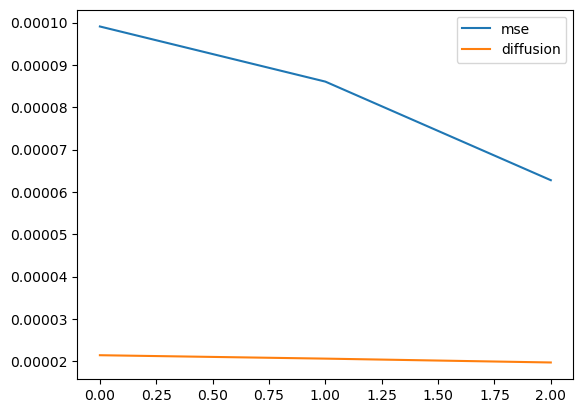

In [30]:
import matplotlib.pyplot as plt
plt.plot(means_grads['mse'], label='mse')
#plt.plot(means_grads['distribution'], label='distribution')
plt.plot(means_grads['diffusion'], label='diffusion')
plt.legend()
plt.show()



In [12]:
x, y = next(iter(trainer.dataloaders['train']))

{"event": "get-batch start", "time": 1748467629.5307288, "pid": 2110854, "batch_idx": 2}
{"event": "get-batch end", "time": 1748467632.978725, "pid": 2110854, "batch_idx": 2, "duration": 3.447993755340576}


In [17]:
trainer.best_losses

{'trial1a': {'mse': inf, 'diffusion': inf, 'distribution': inf},
 'trial1b': {'mse': inf, 'diffusion': inf, 'distribution': inf},
 'trial1c': {'mse': inf, 'diffusion': inf, 'distribution': inf},
 'trial1d': {'mse': inf, 'diffusion': inf, 'distribution': inf}}

In [13]:
batch_losses = trainer._run_batch(x.to(device), y.to(device), 'train', step=0)

{"event": "run-batch start", "time": 1748467662.616888, "pid": 2110854}
{"event": "run-batch end", "time": 1748467662.8276808, "pid": 2110854, "duration": 0.21079063415527344, "loss": 4.592860698699951, "run_id": "trial1a"}
{"event": "run-batch end", "time": 1748467662.9782155, "pid": 2110854, "duration": 0.3613255023956299, "loss": 5.289126396179199, "run_id": "trial1b"}
{"event": "run-batch end", "time": 1748467663.1560235, "pid": 2110854, "duration": 0.5391337871551514, "loss": 4.616513252258301, "run_id": "trial1c"}
{"event": "run-batch end", "time": 1748467663.3137083, "pid": 2110854, "duration": 0.6968183517456055, "loss": 5.320507526397705, "run_id": "trial1d"}


In [23]:
batch_losses

run_id = trainer.run_ids[2]
lw = trainer.training_configs[run_id].loss_weights
l = batch_losses[run_id]
lw, l

({'mse': 1.0, 'distribution': 0.01, 'diffusion': 0.0},
 {'mse': 4.601258277893066,
  'distribution': 1.525495670932516,
  'VAR_IND': 82,
  'diffusion': 0.07281000912189484,
  'total': 4.616513252258301})

In [24]:
total_loss = lw['mse'] * l['mse'] + lw['distribution'] * l['distribution'] + lw['diffusion'] * l['diffusion']

batch_losses[run_id]['total'], total_loss

(4.616513252258301, 4.616513234602391)

In [36]:
from collections import defaultdict
self = trainer
self.distloss_var_counts = {}
for run_id in self.run_ids:
    self.distloss_var_counts[run_id] = defaultdict(int)

In [27]:
trainer.train(num_epochs=1, log=True)

Getting ready to train 4 model(s) for 1 epochs
Saving configs to  /mnt/home/ssa2206/Climsim/experiments/DiffLossTraining/trial1.json
Epoch 1/1
__________


{"event": "epoch-0 start", "time": 1748449308.936858, "pid": 382937}
{"event": "get-batch start", "time": 1748449308.9977887, "pid": 382937, "batch_idx": 2}
{"event": "get-batch end", "time": 1748449313.7843645, "pid": 382937, "batch_idx": 2, "duration": 4.7865684032440186}
{"event": "run-batch start", "time": 1748449313.785193, "pid": 382937}


Currently at epoch 0, step 0/4


InvalidParameterError: The 'n_components' parameter of GaussianMixture must be an int in the range [1, inf). Got [3, 2, 3, 2] instead.

In [62]:
log = trainer.finish_training(log=True, num_epochs=100)

Finished training 100 epochs.


In [12]:
with open(os.path.join(trainer.dirs['log_dir'], 'testing_distloss_a.json'), 'r') as f:
    log_data = json.load(f)

log_data.keys()


dict_keys(['training_config', 'model_config', 'data_config', 'best_loss', 'losses', 'train_loss', 'mse_loss', 'total_loss', 'distribution_loss'])

In [16]:
x, y = trainer.dataloaders['train'].dataset[0]

In [18]:
batch_losses = trainer._run_batch(x.to(device), y.to(device), 'train')

{"event": "run-batch start", "time": 1744078624.836099, "pid": 2475942}
{"event": "run-batch end", "time": 1744078625.155089, "pid": 2475942, "duration": 0.3189873695373535, "loss": 137.5587615966797}
{"event": "run-batch end", "time": 1744078625.459333, "pid": 2475942, "duration": 0.6232316493988037, "loss": 136.02198791503906}
{"event": "run-batch end", "time": 1744078625.790205, "pid": 2475942, "duration": 0.954103946685791, "loss": 149.74610900878906}
{"event": "run-batch end", "time": 1744078626.0908024, "pid": 2475942, "duration": 1.2547011375427246, "loss": 135.84593200683594}


In [38]:
epoch_losses = trainer.log_step(epoch_losses, batch_losses, 32, "train")

In [41]:
batch_losses

{'testing_distloss_a': {'mse': 4.613554000854492,
  'distribution': 132.94520659640085,
  'total': 137.5587615966797},
 'testing_distloss_b': {'mse': 4.6122355461120605,
  'distribution': 131.4097549569163,
  'total': 136.02198791503906},
 'testing_distloss_c': {'mse': 4.62640380859375,
  'distribution': 145.11971086524653,
  'total': 149.74610900878906},
 'testing_distloss_d': {'mse': 4.590487957000732,
  'distribution': 131.25544573709482,
  'total': 135.84593200683594}}

In [42]:
trainer.tracked_losses

['mse',
 'total',
 'distribution',
 'distribution',
 'distribution',
 'distribution']

In [40]:
epoch_losses

defaultdict(dict,
            {'testing_distloss_a': {'mse': [4.613554000854492,
               4.613554000854492,
               4.613554000854492,
               4.613554000854492],
              'total': [137.5587615966797,
               137.5587615966797,
               137.5587615966797,
               137.5587615966797],
              'distribution': [132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085]},
             'testing_distloss_b': {'mse': [4.6122355461120605,
               4.6122355461120605,
               4.6122355461120605,
               4.6122355461120605],
              'total': [136

In [14]:
trainer.losses

{'testing_distloss_a': {'train': [],
  'mse': [4.620398998260498],
  'total': [141.38180541992188],
  'distribution': [136.76140970271769,
   136.76140970271769,
   136.76140970271769,
   136.76140970271769]},
 'testing_distloss_b': {'train': [],
  'mse': [4.6165971755981445],
  'total': [152.74781799316406],
  'distribution': [148.13122720234637,
   148.13122720234637,
   148.13122720234637,
   148.13122720234637]},
 'testing_distloss_c': {'train': [],
  'mse': [4.647116184234619],
  'total': [142.4958038330078],
  'distribution': [137.84869344469078,
   137.84869344469078,
   137.84869344469078,
   137.84869344469078]},
 'testing_distloss_d': {'train': [],
  'mse': [4.618308067321777],
  'total': [216.10232543945312],
  'distribution': [211.48401037725512,
   211.48401037725512,
   211.48401037725512,
   211.48401037725512]}}

# Diffusion Prior Loss

In [8]:
#exp_id = "full_dataset_testrun"
#base_dir = os.path.join("experiments", exp_id)
#run_id = "trial_1b"
#tconfig, mconfig, dconfig = tru.load_config(run_id, exp_id)


In [6]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "trial1"
num_models = 4
base_dir = os.path.join(exp_dir, exp_id)
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)
dconfig.train_test_split = [0.01, 0.002]


In [7]:
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=24576,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [8]:
unet = tru.load_diffusion_model().to(device)
unet.device

device(type='cuda', index=0)

In [13]:
trainer = ClimsimTrainer(
    dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0,
)

In [11]:
#dtconfigs, dmconfigs, ddconfig = setup_diffusion_run(num_models, exp_id, run_id, data_vars='v1', batch_size=128)
#diff_trainer = DiffusionTrainer(ddconfig, dmconfigs, dtconfigs, torch.nn.MSELoss(), base_dir, rank=0)

In [14]:
trainer.dataloaders['train'], len(trainer.dataloaders['train'])

(<torch.utils.data.dataloader.DataLoader at 0x15523bb92450>, 32)

In [15]:
dl = trainer.dataloaders['train']
ds = dl.dataset

ds.dsi

<xarray.Dataset> Size: 801MB
Dimensions:      (time: 2102, lev: 60, ncol: 384)
Coordinates:
  * time         (time) object 17kB 0001-02-01 00:40:00 ... 0001-03-02 05:00:00
  * ncol         (ncol) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    lat          (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon          (ncol) float64 3kB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
Dimensions without coordinates: lev
Data variables:
    state_t      (time, lev, ncol) float64 387MB dask.array<chunksize=(251, 8, 96), meta=np.ndarray>
    state_q0001  (time, lev, ncol) float64 387MB dask.array<chunksize=(251, 8, 96), meta=np.ndarray>
    state_ps     (time, ncol) float64 6MB dask.array<chunksize=(251, 96), meta=np.ndarray>
    pbuf_SOLIN   (time, ncol) float64 6MB dask.array<chunksize=(251, 96), meta=np.ndarray>
    pbuf_LHFLX   (time, ncol) float64 6MB dask.array<chunksize=(251, 96), meta=np.ndarray>
    pbuf_SHFLX   (time, ncol) float64 6MB dask.array<chunksize=(251, 96), meta=np.ndarray>

In [16]:
x, y = ds[0]
x, y = x.to(device), y.to(device)

{"event": "get-batch start", "time": 1748466423.5728226, "pid": 2106584, "batch_idx": 0}
{"event": "get-batch end", "time": 1748466426.7770205, "pid": 2106584, "batch_idx": 0, "duration": 3.2041940689086914}


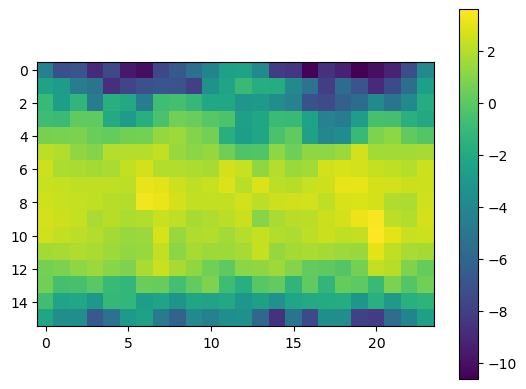

In [19]:
import matplotlib.pyplot as plt
y_img = trainer._make_image(y)
tmap = y_img[5, 59, :, :].detach().cpu().numpy()
plt.imshow(tmap)
plt.colorbar()
plt.show()


In [20]:
"""
dy = diff_trainer.dataloaders['train'].dataset[0]
dyu = dy * ds.ys[None, :, None, None] + ds.ym[None, :, None, None]
dtmap = dyu[5, 59, :, :].detach().cpu().numpy()

plt.imshow(dtmap)
plt.colorbar()
plt.show()
"""
y_hat = clim_trainer.models[clim_trainer.run_ids[0]](x)

In [21]:
y.shape, y_hat.shape

(torch.Size([24576, 128]), torch.Size([24576, 128]))

In [42]:
def diffusion_loss(self, y_hat, run_id):
    #raise NotImplementedError("Diffusion loss not implemented")
    # TODO: y and yhat are of size (B, 128) and somehow need to convert into images for diffusion loss
    tconfig = self.training_configs[run_id]
    scheduler = self.schedulers[run_id]
    y_image = self._make_image(y_hat)
    tconfig.diffusion_loss_noise_level = 10
    print(tconfig.diffusion_loss_noise_level)
    def encode(sample):
        eps = torch.randn(sample.shape, device=sample.device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([tconfig.diffusion_loss_noise_level])) # noisy image
        return(xt)
    def decode(xt):
        with torch.no_grad():
            for t in range(tconfig.diffusion_loss_noise_level, 0, -tconfig.diffusion_loss_decoding_interval):
                eps_theta = self.unet(xt, t).sample
                xt = scheduler.step(eps_theta, t, xt).prev_sample
        return(xt)
    y_image_denoised = decode(encode(y_image))
    return(self.loss_fn(y_image_denoised, y_image))

In [44]:
diff_loss = diffusion_loss(trainer, y_hat, trainer.run_ids[0])
diff_loss

10


tensor(0.0305, device='cuda:0', grad_fn=<MseLossBackward0>)

In [40]:
trainer.loss_fn(y_hat, y)

tensor(4.6545, device='cuda:0', grad_fn=<MseLossBackward0>)

In [46]:
tconfig = trainer.training_configs[trainer.run_ids[0]]
trainer.distribution_loss(y_hat, y, tconfig, step=0)

(tensor(4741.1358, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
 60)

In [103]:
loss_fn = nn.MSELoss()
def image_loss(y, yhat, T: int, unet=ddpm, scheduler=scheduler):
    y, yhat = construct_image(y), construct_image(yhat)
    def encode(sample):
        eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([T])) # noisy image
        return(xt)
    def decode(xt):
        for t in range(T, 0, -1):
            with torch.no_grad():
                eps_theta = unet(xt, t).sample
            xt = scheduler.step(eps_theta, t, xt).prev_sample
        return(xt)
    yhat = decode(encode(yhat))
    return(loss_fn(y, yhat))

In [54]:
image_loss(y.to(device), y_hat, 25)

tensor(1.4329, device='cuda:0', grad_fn=<MseLossBackward0>)

In [76]:
def evaluate_diff(model):
    loss = 0.0
    model.eval()
    with torch.no_grad():
        for idx in range(len(test_ds)):
            print(idx, end=" ")
            x, y = test_ds[idx]
            x, y = x.to(device), y.to(device)
            loss += loss_fn(model(x), y).item()
    return(loss / len(test_ds))

In [121]:
def diffusion_train(model, dataset, loss_fn, tconfig):
    optimizer = torch.optim.Adam(model.parameters(), lr=tconfig.learning_rate, weight_decay=1e-4)
    losses = dict(train=[], diffusion=[], test=[])
    for epoch in range(1, tconfig.num_epochs+1):
        model.train()  # Set the model to training mode
        pixel_loss, img_loss = 0.0, 0.0
        for idx in range(len(dataset)):
            print(idx, end=" ")
            x, y = dataset[idx]
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            ploss = loss_fn(y, y_hat)
            iloss = image_loss(y, y_hat, T=25)
            (ploss + iloss).backward()
            optimizer.step()
            pixel_loss += ploss.item(); img_loss += iloss.item()
            losses['train'].append(ploss.item()); losses['diffusion'].append(iloss.item());
        # Print training progress
        #average_loss = running_loss / len(dataloader)
        #test_loss = evaluate(model).item()
        print(f'\nEpoch [{epoch}/{tconfig.num_epochs}], Pixel Loss: {pixel_loss/len(dataset):.4f}, Image Loss: {img_loss/len(dataset):.4f}')
        
        if(epoch % tconfig.batch_checkpoint_interval == 0):
            print("Saving Model")
            torch.save(model.state_dict(), tconfig.ckpt_id)

    return(model, losses)

## Overfitting two samples

two_sample_ds = ClimsimImageDataset(Xarr[:2*384], Yarr[:2*384], mconfig, device=device, normalize=True)

In [ ]:
#two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
batch = next(iter(two_sample_dl))
noisy_images, timesteps, noise = two_sample_dl.dataset.noise_batch(batch)

optimizer = diff.trainers.create_optimizer(model, tconfig)
lr_scheduler = load_lr_scheduler(tconfig, optimizer, two_sample_dl)

In [ ]:
pred = model(noisy_images, timesteps).sample
loss = loss_fn(pred, noise)
loss

In [ ]:
loss.backward()

In [ ]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

In [ ]:
torch.norm(list(model.parameters())[0].grad)

In [ ]:
set = {'train' : two_sample_ds}
trainer = DiffusionTrainer(model, dset, loss_fn, tconfig, mconfig, exp_id='two_sample_diffusion')
#trainer.dataloaders = {'train' : two_sample_dl}
#trainer.batch = next(iter(two_sample_dl)) # use same noise every time
trainer.train(1000)

In [ ]:
plt.plot(trainer.losses)

In [ ]:
from diffusers.optimization import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = load_lr_scheduler(tconfig, )

In [ ]:
from diffusers import DDPMPipeline
from diffusers.utils import make_image_grid
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.Generator(device=device).manual_seed(config.seed), # Use a separate torch generator to avoid rewinding the random state of the main training loop
    ).images

    # Make a grid out of the images
    image_grid = make_image_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        #log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )
    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")


    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, clean_images in enumerate(train_dataloader):
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            )

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        try:
            if accelerator.is_main_process:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
    
                if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                    evaluate(config, epoch, pipeline)
    
                if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                    if config.push_to_hub:
                        upload_folder(
                            repo_id=repo_id,
                            folder_path=config.output_dir,
                            commit_message=f"Epoch {epoch}",
                            ignore_patterns=["step_*", "epoch_*"],
                        )
                    else:
                        pipeline.save_pretrained(config.output_dir)
        except: 
            print("Ran into error with sampling and evaluating")
        
        return(model)

In [ ]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, dataloader, lr_scheduler)

model = notebook_launcher(train_loop, args, num_processes=1)